In [1]:
from sashimi_c import *
import matplotlib.pyplot as plt

plt.rc('font', **{'family':'sans-serif','size':15})
plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams['xtick.major.size']  = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size']  = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 5
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.size']  = 2
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['xtick.major.pad']   = 8
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True

In [2]:
%prun obs_odeint = subhalo_observables(M0_per_Msun=1.e12,dz=0.1,method="odeint",atol=1e-10,rtol=1e-10)

         3137083 function calls in 5.069 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
   123444    1.007    0.000    1.047    0.000 sashimi_c.py:142(conc200)
    61618    0.486    0.000    2.267    0.000 sashimi_c.py:192(Mzzi)
    61619    0.454    0.000    1.093    0.000 sashimi_c.py:184(Mzi)
    61687    0.344    0.000    1.945    0.000 sashimi_c.py:168(Mvir_from_M200_fit)
    61687    0.336    0.000    0.336    0.000 sashimi_c.py:176(xfunc)
   246482    0.336    0.000    0.793    0.000 sashimi_c.py:121(sigmaMz)
   123238    0.322    0.000    0.481    0.000 sashimi_c.py:97(dDdz)
   308103    0.291    0.000    0.291    0.000 sashimi_c.py:89(growthD)
   739451    0.222    0.000    0.222    0.000 sashimi_c.py:117(xi)
    12313    0.211    0.000    4.614    0.000 sashimi_c.py:342(msolve)
        1    0.175    0.175    0.175    0.175 sashimi_c.py:628(Ffunc_Yang)
    61687    0.154    0.000    0.154    0.000 sashimi_c.py:174

In [3]:
%prun obs_pert2  = subhalo_observables(M0_per_Msun=1.e12,dz=0.1,method='pert2_shanks')

         26514 function calls in 0.404 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.175    0.175    0.175    0.175 sashimi_c.py:628(Ffunc_Yang)
        1    0.086    0.086    0.309    0.309 sashimi_c.py:634(Na_calc)
        1    0.022    0.022    0.395    0.395 sashimi_c.py:692(subhalo_properties_calc)
      314    0.015    0.000    0.017    0.000 sashimi_c.py:142(conc200)
        1    0.009    0.009    0.009    0.009 ufunclike.py:71(isposinf)
        1    0.008    0.008    0.404    0.404 sashimi_c.py:840(__init__)
      213    0.008    0.000    0.008    0.000 hermite.py:1516(_normed_hermite_n)
      357    0.007    0.000    0.007    0.000 {built-in method numpy.array}
        1    0.007    0.007    0.007    0.007 ufunclike.py:142(isneginf)
        1    0.006    0.006    0.030    0.030 type_check.py:403(nan_to_num)
        1    0.006    0.006    0.006    0.006 {method 'argmin' of 'numpy.ndarray' objects}
 

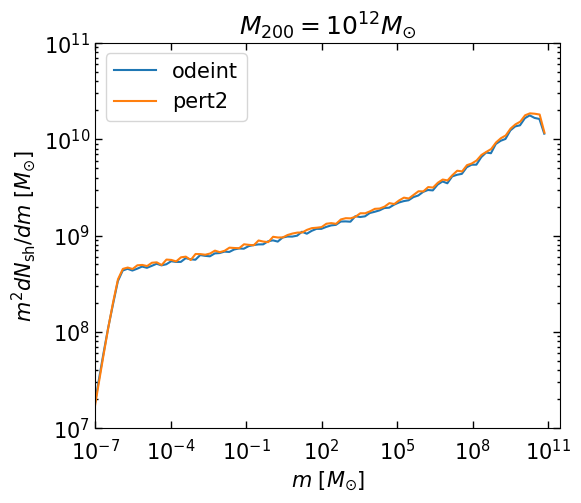

In [4]:
plt.figure(figsize=(6,5))
for method,obs in zip(["odeint","pert2"],[obs_odeint, obs_pert2]):
    m,dNdlnm = obs.mass_function()
    plt.loglog(m,m*dNdlnm, label=method)
plt.xlim(1.e-7,3.e11)
plt.ylim(1.e7,1.e11)
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$m^{2}dN_{\rm sh}/dm$ [$M_{\odot}$]')
plt.title(r'$M_{200}=10^{12}M_{\odot}$')
plt.legend()
plt.show()

Next, we demonstrate how to plot cumulative number of satellite galaxies, assuming that they form in a host subhalo with its peak mass greater than some threshold value. In this example, we adopt $M_{\rm peak}^{\rm th} = 10^{8} M_{\odot}$. Top panel is plotted as a function of subhalo mass $m$ and the bottom as a function of maximum circular velocity $V_{\rm max}$.

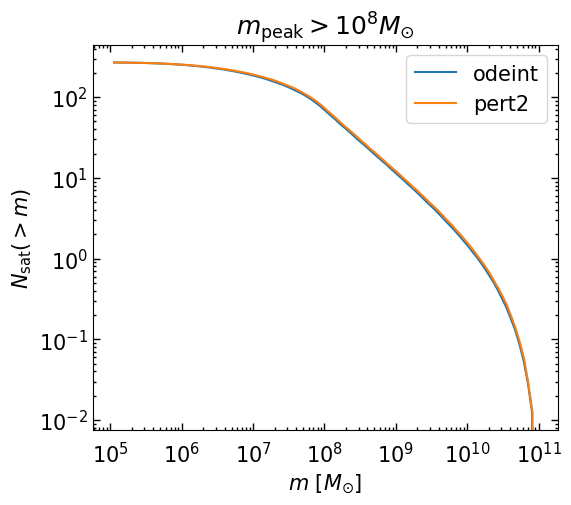

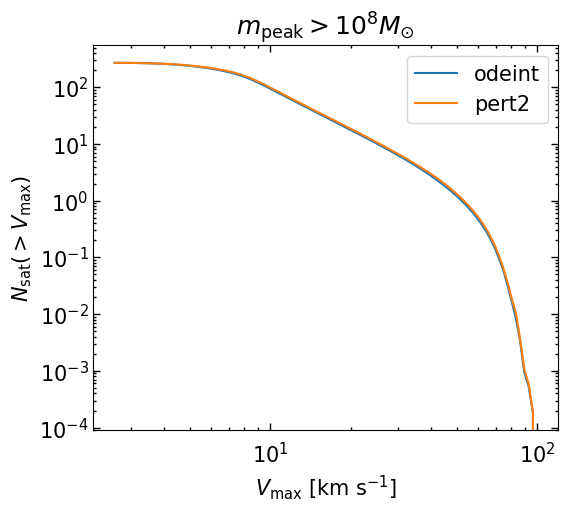

In [15]:
plt.figure(figsize=(6,5))
m,Nccum_m,Vmax,Nccum_Vmax = obs_odeint.Nsat_Mpeak(1.e8*obs.Msun)
plt.loglog(m,Nccum_m,label='odeint')
m,Nccum_m,Vmax,Nccum_Vmax = obs_pert2.Nsat_Mpeak(1.e8*obs.Msun)
plt.loglog(m,Nccum_m,label='pert2')
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$N_{\rm sat}(>m)$')
plt.title(r'$m_{\rm peak}>10^{8}M_{\odot}$')
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
m,Nccum_m,Vmax,Nccum_Vmax = obs_odeint.Nsat_Mpeak(1.e8*obs.Msun)
plt.loglog(Vmax,Nccum_Vmax,label='odeint')
m,Nccum_m,Vmax,Nccum_Vmax = obs_pert2.Nsat_Mpeak(1.e8*obs.Msun)
plt.loglog(Vmax,Nccum_Vmax,label='pert2')
plt.xlabel(r'$V_{\rm max}$ [km s$^{-1}$]')
plt.ylabel(r'$N_{\rm sat}(>V_{\rm max})$')
plt.title(r'$m_{\rm peak}>10^{8}M_{\odot}$')
plt.legend()
plt.show()

Now the same plots but by assuming that the satellites form in a host subhalo with peak value of $V_{\rm max}$, $V_{\rm peak}$, that is larger than some threshold value. In this example, we show the case of $V_{\rm peak}^{\rm th} = 18 ~ \mathrm{km/s}$.

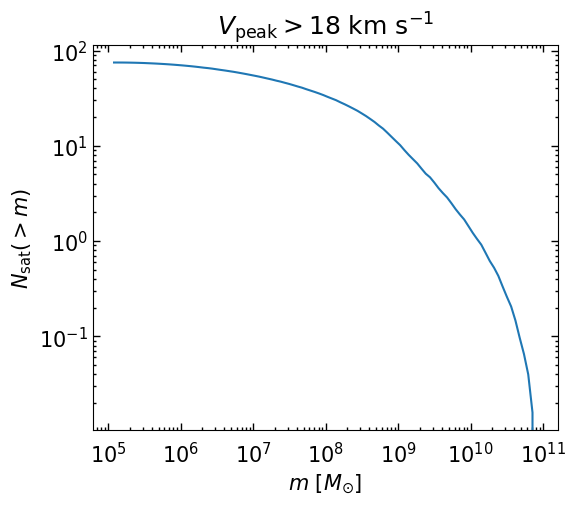

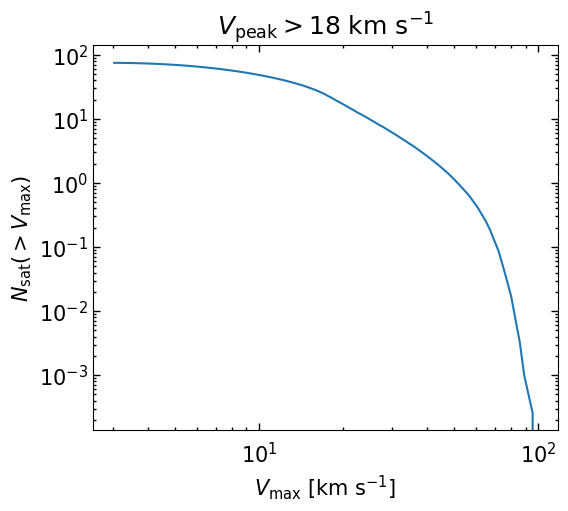

In [5]:
m,Nccum_m,Vmax,Nccum_Vmax = obs.Nsat_Vpeak(18.*obs.km/obs.s)
plt.figure(figsize=(6,5))
plt.loglog(m,Nccum_m)
plt.xlabel(r'$m$ [$M_{\odot}$]')
plt.ylabel(r'$N_{\rm sat}(>m)$')
plt.title(r'$V_{\rm peak}>18$ km s$^{-1}$')
plt.show()

plt.figure(figsize=(6,5))
plt.loglog(Vmax,Nccum_Vmax)
plt.xlabel(r'$V_{\rm max}$ [km s$^{-1}$]')
plt.ylabel(r'$N_{\rm sat}(>V_{\rm max})$')
plt.title(r'$V_{\rm peak}>18$ km s$^{-1}$')
plt.show()

# Annihilation boost factor

One can calculate the annihilation boost factor 
$B_{\rm sh} = L_{\rm sh}/L_{\rm host,0}$.
We also show the ratio of total luminosity due to annihilation (host+subhalos) and the host luminosity. Ando et al. arXiv:1903.11427 discuss that this is obtained as
$L_{\rm sh}/L_{\rm host,0} = 1-f_{\rm sh}^2+B_{\rm sh}$
where $f_{\rm sh}$ is the subhalo mass fraction.

In [9]:
obs.annihilation_boost_factor()

(1.8586738558142708, 2.8430529363577772)

# Making a subhalo catalog

Finally, it might be sometimes interesting to generate a sample of subhalos using the Monte Carlo simulations. This can be done with a given threshold mass as follows.

In [14]:
ma200,z_a,rs_a,rhos_a,m0,rs0,rhos0,ct0 = obs_pert2.subhalo_catalog_MC(mth=1.e8*obs.Msun)

Here each of these parameters such as ma200 is a list of values. Each entry correspond to one subhalo.

For example, one can plot cumulative mass function as follows.

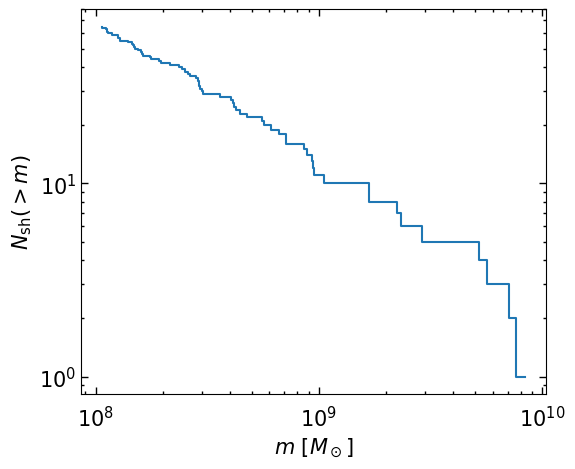

In [15]:
plt.figure(figsize=(6,5))
plt.xscale('log')
plt.yscale('log')
plt.step(np.sort(m0),np.arange(1,len(m0)+1)[::-1])
plt.xlabel(r'$m$ [$M_\odot$]')
plt.ylabel(r'$N_{\rm sh}(>m)$')
plt.show()

And scatter plots of density profile parameters $r_s$ and $\rho_s$.

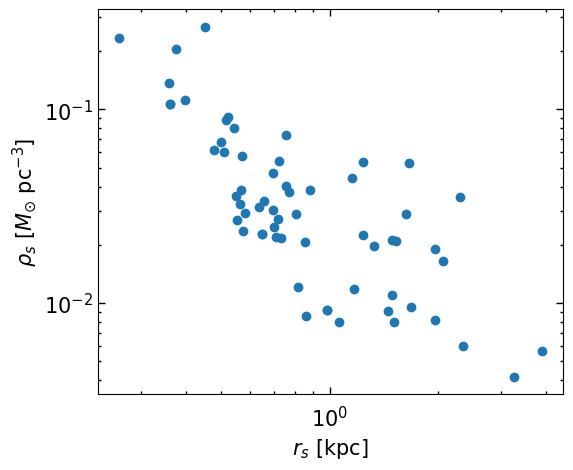

In [20]:
plt.figure(figsize=(6,5))
plt.xscale('log')
plt.yscale('log')
plt.scatter(rs0,rhos0)
plt.xlabel(r'$r_s$ [kpc]')
plt.ylabel(r'$\rho_s$ [$M_{\odot} \ \mathrm{pc^{-3}}$]')
plt.show()